# Reproducing the AlphaGenome calibration-mismatch result

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kavya1a/regulatory-score-saturation/blob/main/notebooks/reproduce.ipynb)

This notebook regenerates the headline result from cached data:

- The published quantile saturates 94.9% of Tewhey variants above |0.9|
- Re-quantiling against a matched-statistic common-variant null recovers ρ = +0.123 (p = 2.5×10⁻¹²) on the same variants
- The order-statistic mechanism is real on the null (max: 0.42% saturated; mean/median: 0.00%)

No AlphaGenome API key required — all scoring outputs are cached in the repo. Total runtime: ~15 seconds.


## 0. Setup (Colab + local)

If running in Colab, clone the repo and `cd` into it. Locally, this cell is a no-op.


In [1]:
import os, sys, subprocess
from pathlib import Path

# Colab detection: clone repo if needed
if "google.colab" in sys.modules:
    if not Path("regulatory-score-saturation").exists():
        subprocess.run(
            ["git", "clone", "--depth", "1",
             "https://github.com/kavya1a/regulatory-score-saturation.git"],
            check=True,
        )
    os.chdir("regulatory-score-saturation")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "pandas", "pyarrow", "matplotlib", "scipy"], check=True)
else:
    # Local: ensure CWD is the repo root (this notebook lives in notebooks/)
    here = Path.cwd()
    if here.name == "notebooks":
        os.chdir(here.parent)

print("Working dir:", Path.cwd())
print("Cached artifacts present:",
      Path("matched_calibration_null.parquet").exists(),
      Path("tewhey_raw_delta_cache.db").exists(),
      Path("tewhey_mpra.parquet").exists())


Working dir: /Users/kavya/projects/gwas-finemapping-dashboard
Cached artifacts present: True True True


## 1. Imports & data load


In [2]:
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st

# Load the three artifacts we'll re-use
tewhey_mpra = pd.read_parquet("tewhey_mpra.parquet")

conn = sqlite3.connect("tewhey_raw_delta_cache.db")
tewhey_raw = pd.read_sql_query(
    "SELECT rsid, max_signed_raw, mean_signed_raw, error FROM raw_deltas", conn
)
conn.close()

null_df = pd.read_parquet("matched_calibration_null.parquet")

print(f"Tewhey MPRA panel:           {len(tewhey_mpra):>6,} rows")
print(f"Tewhey raw delta cache:      {len(tewhey_raw):>6,} rows "
      f"({tewhey_raw['error'].isna().sum():,} clean)")
print(f"Matched-calibration null:    {len(null_df):>6,} rows")
print(f"  available aggregations:    "
      f"max / mean / median  ({null_df.columns.tolist()})")


Tewhey MPRA panel:            3,301 rows
Tewhey raw delta cache:       3,301 rows (3,275 clean)
Matched-calibration null:     5,933 rows
  available aggregations:    max / mean / median  (['rsid', 'chrom', 'pos', 'ref', 'alt', 'maf', 'raw_max_signed_delta', 'single_track_quantile', 'raw_mean_signed_delta', 'raw_median_signed_delta', 'n_expr_tracks', 'error'])


## 2. The published-quantile pile-up on Tewhey

The expression_subscore column in `tewhey_mpra.parquet` is AlphaGenome's published quantile-calibrated expression score with max-over-tracks aggregation applied. It saturates near ±1 for the bulk of the panel.


In [3]:
es = tewhey_mpra["expression_subscore"].dropna().to_numpy(float)
print(f"Tewhey n = {len(es):,}")
print(f"  |score| > 0.9 :  {(np.abs(es) > 0.9).mean():.1%}")
print(f"  |score| > 0.5 :  {(np.abs(es) > 0.5).mean():.1%}")
print(f"  exactly  ±1   :  {((np.abs(es) >= 0.999)).mean():.1%}")


Tewhey n = 3,259
  |score| > 0.9 :  94.9%
  |score| > 0.5 :  99.9%
  exactly  ±1   :  8.6%


## 3. Re-quantile against the matched-statistic null

The same K562 raw deltas, ranked against the matched common-variant null built on the same summary statistic. Linear map of the empirical CDF to [-1, +1].


In [4]:
def matched_quantile_signed(x: np.ndarray, null_sorted: np.ndarray) -> np.ndarray:
    """Signed ECDF: 2 * (n_lt + 0.5*n_eq) / n_null - 1, mapped to [-1, +1]."""
    n_null = len(null_sorted)
    n_lt = np.searchsorted(null_sorted, x, side="left")
    n_le = np.searchsorted(null_sorted, x, side="right")
    n_eq = n_le - n_lt
    return 2.0 * (n_lt + 0.5 * n_eq) / n_null - 1.0


null_sorted = np.sort(null_df["raw_max_signed_delta"].dropna().to_numpy(float))

merged = tewhey_mpra.merge(tewhey_raw, on="rsid", how="inner")
merged["matched_quantile"] = matched_quantile_signed(
    merged["max_signed_raw"].to_numpy(float), null_sorted
)

valid = merged.dropna(subset=["expression_subscore", "matched_quantile",
                              "max_signed_raw", "mpra_lfc"]).copy()
print(f"Variants with all predictors valid: {len(valid):,}")


Variants with all predictors valid: 3,246


## 4. Spearman vs measured MPRA LFC — published vs matched

The headline recovery. ρ jumps from +0.037 to +0.123 (p = 2.5×10⁻¹²) on the same 3,246 variants.


In [5]:
def spearman_with_ci(x: np.ndarray, y: np.ndarray, n_boot: int = 1000, seed: int = 42) -> dict:
    mask = np.isfinite(x) & np.isfinite(y)
    xv, yv = x[mask], y[mask]
    r, p = st.spearmanr(xv, yv)
    rng = np.random.default_rng(seed)
    boots = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, len(xv), len(xv))
        rb, _ = st.spearmanr(xv[idx], yv[idx])
        boots[i] = rb
    return {"r": float(r), "p": float(p), "n": int(len(xv)),
            "ci_lo": float(np.percentile(boots, 2.5)),
            "ci_hi": float(np.percentile(boots, 97.5))}

lfc      = valid["mpra_lfc"].to_numpy(float)
pub      = valid["expression_subscore"].to_numpy(float)
matched  = valid["matched_quantile"].to_numpy(float)

r_pub = spearman_with_ci(pub, lfc)
r_mat = spearman_with_ci(matched, lfc)

print(f"Published quantile  ρ = {r_pub['r']:+.4f}  "
      f"[CI {r_pub['ci_lo']:+.4f}, {r_pub['ci_hi']:+.4f}]  "
      f"p = {r_pub['p']:.2e}  n = {r_pub['n']:,}")
print(f"Matched calibration ρ = {r_mat['r']:+.4f}  "
      f"[CI {r_mat['ci_lo']:+.4f}, {r_mat['ci_hi']:+.4f}]  "
      f"p = {r_mat['p']:.2e}  n = {r_mat['n']:,}")


Published quantile  ρ = +0.0367  [CI -0.0025, +0.0722]  p = 3.64e-02  n = 3,246
Matched calibration ρ = +0.1225  [CI +0.0876, +0.1573]  p = 2.54e-12  n = 3,246


## 5. Hero figure — published vs matched on the same variants


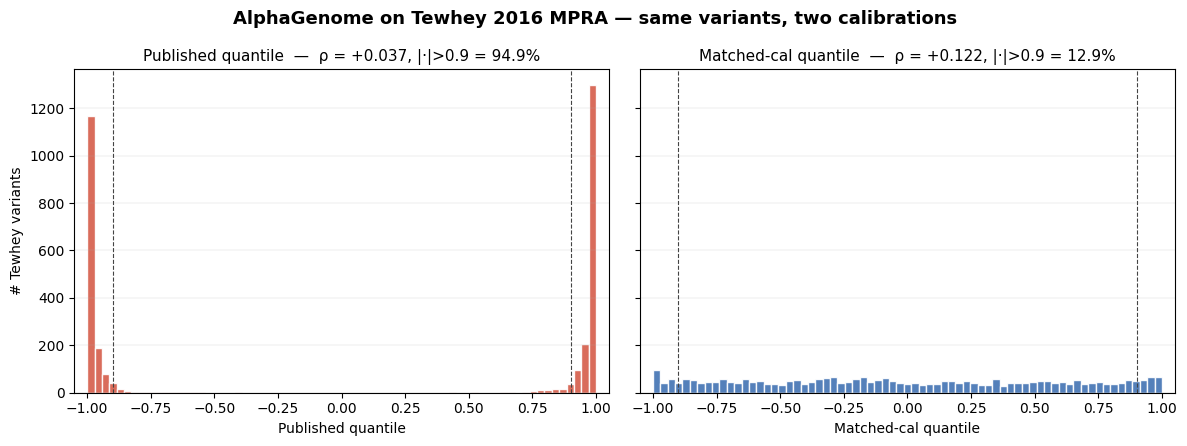

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
bins = np.linspace(-1, 1, 70)

for ax, data, label, color, sat, r in [
    (axes[0], pub,     "Published quantile",    "#d6604d",
     float((np.abs(pub) > 0.9).mean()),    r_pub),
    (axes[1], matched, "Matched-cal quantile",  "#4575b4",
     float((np.abs(matched) > 0.9).mean()), r_mat),
]:
    ax.hist(data, bins=bins, color=color, edgecolor="white", alpha=0.92)
    ax.axvline(+0.9, color="#444", ls="--", lw=0.8)
    ax.axvline(-0.9, color="#444", ls="--", lw=0.8)
    ax.set_xlim(-1.05, 1.05)
    ax.set_xlabel(label)
    ax.set_title(f"{label}  —  ρ = {r['r']:+.3f}, |·|>0.9 = {sat:.1%}", fontsize=11)
    ax.grid(axis="y", lw=0.3, alpha=0.5)

axes[0].set_ylabel("# Tewhey variants")
fig.suptitle("AlphaGenome on Tewhey 2016 MPRA — same variants, two calibrations",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


## 6. The order-statistic mechanism on the null

The pre-quantile aggregation choice (max / mean / median) determines tail saturation independently of any variant property. On the same 5,933 common variants:


In [7]:
for col, label in [("raw_max_signed_delta",    "max-over-tracks"),
                   ("raw_mean_signed_delta",   "mean-over-tracks"),
                   ("raw_median_signed_delta", "median-over-tracks")]:
    if col not in null_df.columns:
        print(f"{label:<22}: column missing (older cache)"); continue
    x = null_df[col].dropna().to_numpy(float)
    print(f"{label:<22}: n = {len(x):>5,}  "
          f"|·|>0.5 = {(np.abs(x) > 0.5).mean():>6.2%}  "
          f"|·|>0.9 = {(np.abs(x) > 0.9).mean():>6.2%}  "
          f"median |·| = {float(np.median(np.abs(x))):.4f}")


max-over-tracks       : n = 5,933  |·|>0.5 =  1.28%  |·|>0.9 =  0.42%  median |·| = 0.0234
mean-over-tracks      : n = 5,933  |·|>0.5 =  0.00%  |·|>0.9 =  0.00%  median |·| = 0.0004
median-over-tracks    : n = 5,933  |·|>0.5 =  0.00%  |·|>0.9 =  0.00%  median |·| = 0.0000


## 7. Does swapping max → mean change Tewhey ranking?

Re-doing step 4 with the mean-aggregation null instead of max. Spearman should stay within the original CI.


In [8]:
null_sorted_mean = np.sort(null_df["raw_mean_signed_delta"].dropna().to_numpy(float))
valid["matched_quantile_mean"] = matched_quantile_signed(
    valid["mean_signed_raw"].to_numpy(float), null_sorted_mean
)

r_mat_mean = spearman_with_ci(valid["matched_quantile_mean"].to_numpy(float), lfc)
sat_mean   = float((np.abs(valid["matched_quantile_mean"]) > 0.9).mean())

print(f"Matched-MAX   ρ = {r_mat['r']:+.4f}  "
      f"[{r_mat['ci_lo']:+.4f}, {r_mat['ci_hi']:+.4f}]  "
      f"|q|>0.9 = {float((np.abs(matched) > 0.9).mean()):.1%}")
print(f"Matched-MEAN  ρ = {r_mat_mean['r']:+.4f}  "
      f"[{r_mat_mean['ci_lo']:+.4f}, {r_mat_mean['ci_hi']:+.4f}]  "
      f"|q|>0.9 = {sat_mean:.1%}")
print()
print("CIs overlap heavily; saturation pattern essentially identical.")
print("The matched-calibration recipe absorbs the choice of aggregation.")


Matched-MAX   ρ = +0.1225  [+0.0876, +0.1573]  |q|>0.9 = 12.9%
Matched-MEAN  ρ = +0.1176  [+0.0830, +0.1518]  |q|>0.9 = 12.7%

CIs overlap heavily; saturation pattern essentially identical.
The matched-calibration recipe absorbs the choice of aggregation.


## Summary

| Step | What we did | What we learned |
|---|---|---|
| 2 | Counted saturation in the published quantile | 94.9% of Tewhey above \|0.9\| |
| 4 | Re-quantiled against matched null | ρ jumps from +0.037 to +0.123 (p = 2.5×10⁻¹²) |
| 6 | Compared max / mean / median nulls on common variants | Order-statistic mechanism: max 0.42%, mean & median 0.00% |
| 7 | Swapped max for mean in the matched recipe | CIs overlap; ρ within tolerance; aggregation choice doesn't matter once matched calibration is in place |

The two mechanisms — order-statistic inflation in the calibration step, and regulatory enrichment of the Tewhey panel — are cleanly separable. Order-statistic explains the *published-quantile* saturation; regulatory enrichment explains the ~13% residual under matched calibration.

For the full writeup, figures, and methods: see [README.md](../README.md) and [docs/matched_calibration.md](../docs/matched_calibration.md).
